In [1]:
# --------------------------------------------------------------
# 0️⃣  Imports
# --------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
# import pmdarima as pm          # only for optional auto_arima
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [2]:
# !pip install pmdarima
# !pip install --upgrade statsmodels pmdarima
# import statsmodels
# import pmdarima as pm    
# !pip uninstall -y pmdarima

In [3]:
# --------------------------------------------------------------
# 1️⃣  Load the data
# --------------------------------------------------------------
url = "https://raw.githubusercontent.com/Tathagatd96/RNN-for-predicting-milk-production-/master/monthly-milk-production.csv"
df = pd.read_csv(url)

# The CSV looks like:
#   Month,Milk
#   1975-01,  9658.0
#   …
df.head()

,Month,Milk Production
0,1962-01-01 01:00:00,589.0
1,1962-02-01 01:00:00,561.0
2,1962-03-01 01:00:00,640.0
3,1962-04-01 01:00:00,656.0
4,1962-05-01 01:00:00,727.0


In [4]:
df = df.reset_index()
df.columns

Index(['index', 'Month', 'Milk Production'], dtype='object')

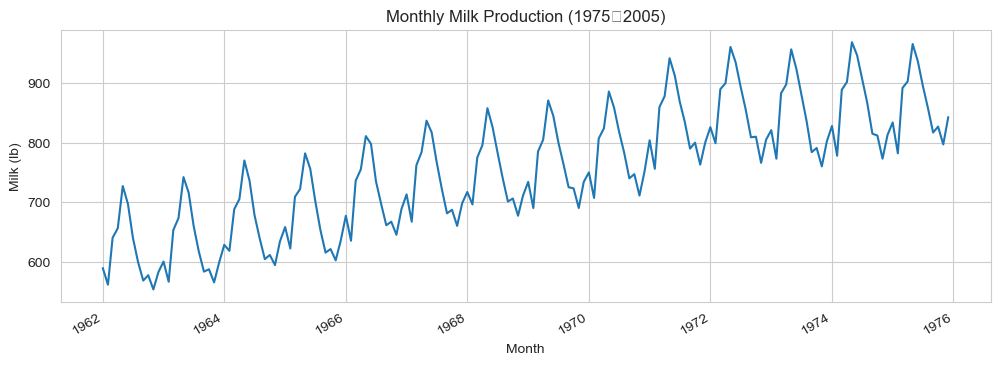

In [5]:
# --------------------------------------------------------------
# 2️⃣  Parse the date column and set index
# --------------------------------------------------------------
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Ensure a proper datetime frequency (monthly)
df = df.asfreq('MS')               # 'MS' = month start
ts = df['Milk Production']

# --------------------------------------------------------------
# 3️⃣  Visualise the raw series
# --------------------------------------------------------------
plt.figure(figsize=(12,4))
ts.plot()
plt.title('Monthly Milk Production (1975‑2005)')
plt.ylabel('Milk (lb)')
plt.show()

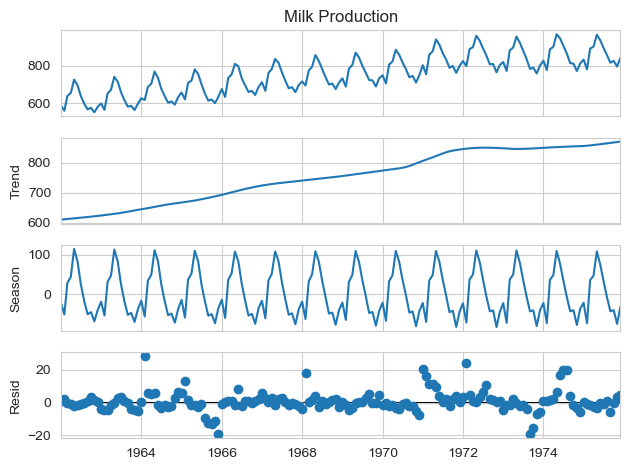

In [6]:
# STL is robust and works for any season length (here 12 months)
stl = STL(ts, period=12, robust=True)
result = stl.fit()

trend = result.trend
seasonal = result.seasonal
resid = result.resid

# Plot the three components
result.plot()
plt.show()

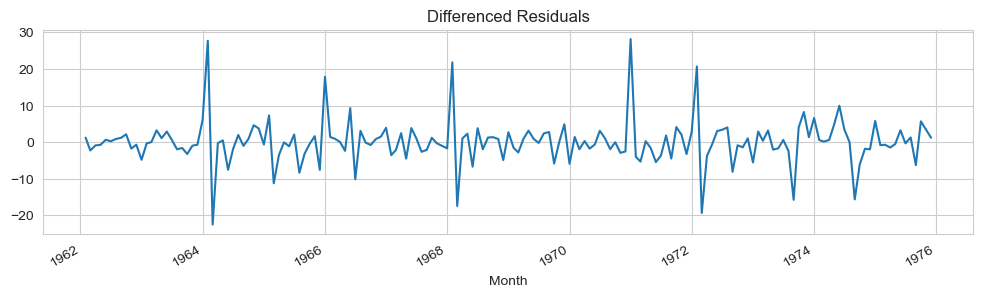

In [7]:
# First‑order differencing of the residuals
diff_resid = resid.diff().dropna()

# Quick check of stationarity (visual)
diff_resid.plot(figsize=(12,3), title='Differenced Residuals')
plt.show()

differenced plot looks like random noise centered around zero-->successfully removed the trend.

In [9]:
from statsmodels.tsa.stattools import adfuller
adf_res = adfuller(diff_resid)
print('ADF statistic:', adf_res[0])
print('p‑value:', adf_res[1])

ADF statistic: -8.29065583491816
p‑value: 4.270695690589179e-13


A p‑value < 0.05 → we can treat the series as stationary.

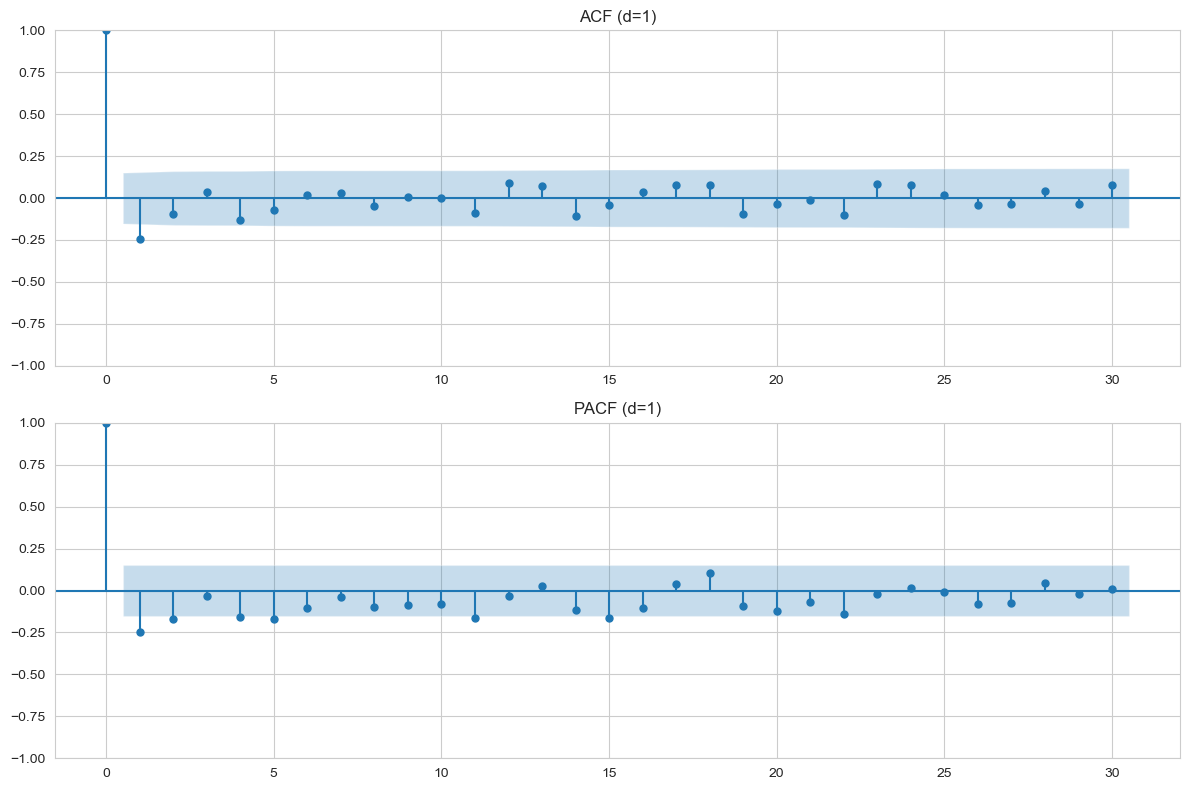

In [11]:
fig, ax = plt.subplots(2,1, figsize=(12,8))

# ACF of differenced residuals
plot_acf(diff_resid, ax=ax[0], lags=30, title='ACF (d=1)')

# PACF of differenced residuals
plot_pacf(diff_resid, ax=ax[1], lags=30, method='ywm', title='PACF (d=1)')

plt.tight_layout()
plt.show()

A common starting point is (p,d,q) = (1,1,1) for the residual series (already differenced once, so
d=0 for diff_resid

In [21]:
# auto_model = pm.auto_arima(
#     resid,
#     start_p=0, max_p=4,
#     start_q=0, max_q=4,
#     d=None,           # let it figure out differencing
#     seasonal=False,   # we already removed seasonality
#     stepwise=True,
#     suppress_warnings=True,
#     information_criterion='aic'
# )

# print(auto_model.summary())

In [23]:
p, d, q = 1, 1, 1

model = ARIMA(resid, order=(p,d,q))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                  168
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -521.355
Date:                Thu, 19 Mar 2026   AIC                           1048.710
Time:                        05:59:18   BIC                           1058.064
Sample:                    01-01-1962   HQIC                          1052.506
                         - 12-01-1975                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5419      0.054      9.971      0.000       0.435       0.648
ma.L1         -0.9995      0.662     -1.511      0.131      -2.296       0.297
sigma2        29.4546     19.051      1.546      0.1

## Forecast the residuals (future horizon)

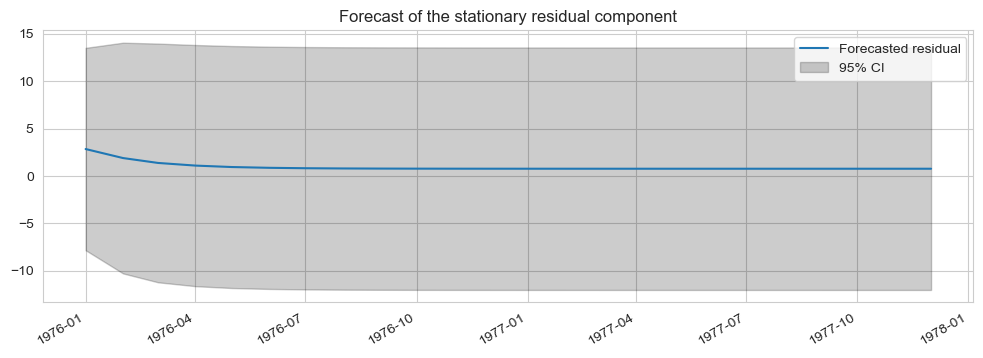

In [25]:
n_forecast = 24          # e.g., two years ahead
forecast_resid = model_fit.get_forecast(steps=n_forecast)
forecast_resid_mean = forecast_resid.predicted_mean
forecast_resid_ci   = forecast_resid.conf_int()

# Plot the residual forecast
plt.figure(figsize=(12,4))
forecast_resid_mean.plot(label='Forecasted residual')
plt.fill_between(forecast_resid_ci.index,
                 forecast_resid_ci.iloc[:,0],
                 forecast_resid_ci.iloc[:,1],
                 color='k', alpha=0.2, label='95% CI')
plt.title('Forecast of the stationary residual component')
plt.legend()
plt.show()

## Re‑integrate trend + seasonality

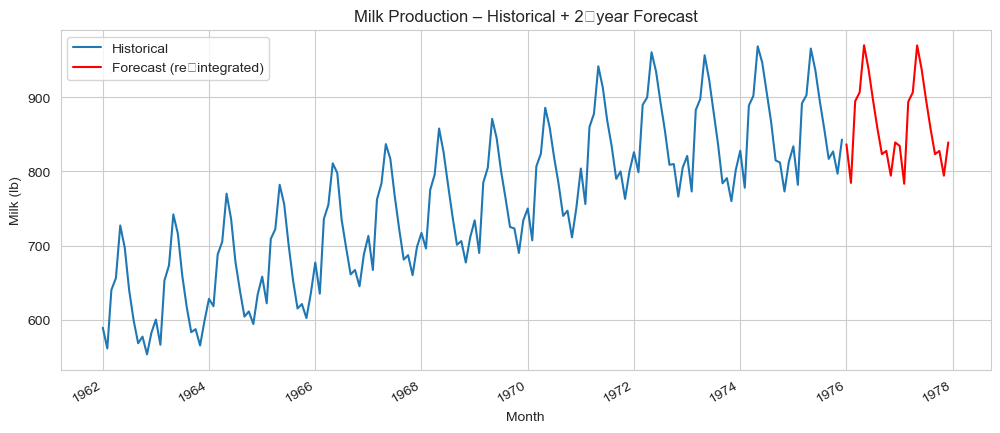

In [35]:
# Extend trend and seasonal components forward
# We'll simply repeat the last observed trend and seasonal pattern
last_trend = trend[-12:]               # last year of trend
last_season = seasonal[-12:]           # last year of seasonality
trend_forecast = pd.Series(
    np.tile(last_trend.values, int(np.ceil(n_forecast/12)))[:n_forecast],
    index=forecast_resid_mean.index
)
season_forecast = pd.Series(
    np.tile(last_season.values, int(np.ceil(n_forecast/12)))[:n_forecast],
    index=forecast_resid_mean.index
)

# Final forecast on original scale
final_forecast = forecast_resid_mean + trend_forecast + season_forecast

# Plot together with historical data
plt.figure(figsize=(12,5))
ts.plot(label='Historical')
final_forecast.plot(label='Forecast (re‑integrated)', color='red')
plt.title('Milk Production – Historical + 2‑year Forecast')
plt.ylabel('Milk (lb)')
plt.legend()
plt.show()